# Análisis Exploratorio de los Datos - EDA
---

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
# Ruta raíz del proyecto (cwd = donde se encuentra el notebook; .parent = ruta padre, eso da la ruta raíz)
PROJECT_ROOT = Path.cwd().parent

RAW_PATH = PROJECT_ROOT / "data" / "processed" / "bank_marketing.csv"

df = pd.read_csv(RAW_PATH)

### 1. Balance de la variable objetivo

Se analiza la distribución de la variable objetivo `y` para determinar si existe un desbalance entre las clases `yes` y `no`. Este análisis es relevante para definir la estrategia de evaluación y entrenamiento de los modelos predictivos.

In [4]:
# Distribución de la variable objetivo

conteo_y = df["y"].value_counts()
porcentaje_y = df["y"].value_counts(normalize=True) * 100

print("Cantidad de registros por clase:")
print(conteo_y)

print("\nPorcentaje de registros por clase:")
print(porcentaje_y.round(2))

Cantidad de registros por clase:
y
no     39922
yes     5289
Name: count, dtype: int64

Porcentaje de registros por clase:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


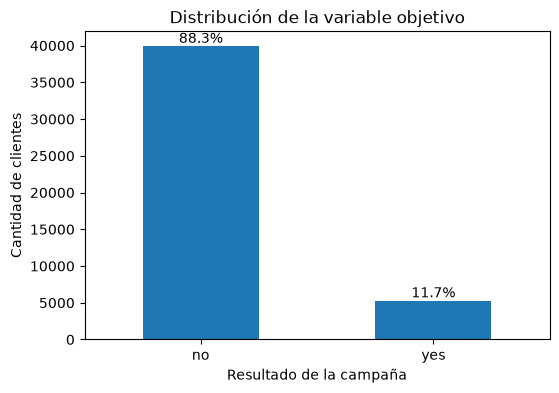

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

ax = conteo_y.plot(kind="bar")

plt.title("Distribución de la variable objetivo")
plt.xlabel("Resultado de la campaña")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)

for i, valor in enumerate(conteo_y):
    porcentaje = porcentaje_y.iloc[i]
    ax.text(i, valor, f"{porcentaje:.1f}%", ha="center", va="bottom")

plt.show()

**Interpretación**

La variable objetivo presenta un desbalance considerable. El 88.3% de los clientes no aceptó la oferta (`no`), mientras que solamente el 11.7% la aceptó (`yes`). Esto significa que la clase positiva es minoritaria y que un modelo podría favorecer la clase `no` si se evalúa únicamente mediante Accuracy.

**Decisión de modelado**

Debido al desbalance observado, la evaluación de los modelos no se basará únicamente en Accuracy. Se utilizarán métricas como Precision, Recall, F1-score y ROC-AUC para evaluar adecuadamente la capacidad del modelo para identificar la clase `yes`. Además, se evaluará el uso de ponderación de clases durante el entrenamiento.

---

### 2. Distribución de Variables Númericas

Se analiza la distribución de las variables numéricas para identificar diferencias de escala, asimetrías y concentraciones de valores que puedan influir en el preprocesamiento y selección de los modelos.

In [6]:
# Identificar variables numéricas

variables_numericas = df.select_dtypes(include="number").columns

print("Variables numéricas:")
print(list(variables_numericas))

Variables numéricas:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


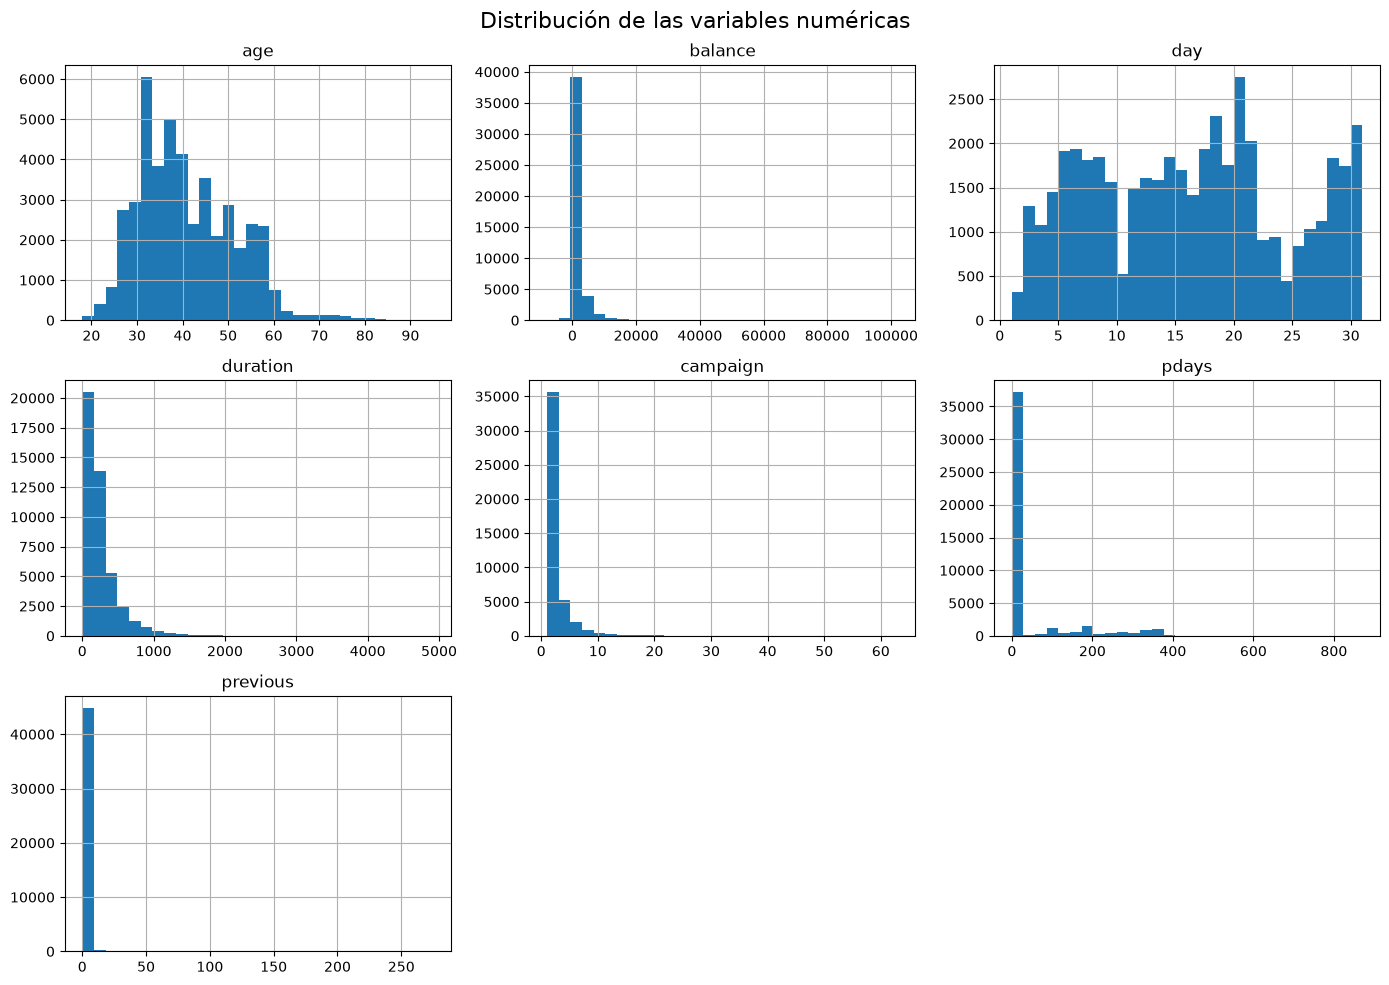

In [7]:
df[variables_numericas].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distribución de las variables numéricas", fontsize=16)
plt.tight_layout()
plt.show()

**Interpretación**

Las variables numéricas presentan distribuciones diferentes. `age` muestra una concentración principalmente entre los 25 y 60 años, mientras que `day` presenta una distribución irregular a lo largo del mes.

Por otro lado, `balance`, `duration`, `campaign`, `pdays` y `previous` presentan distribuciones asimétricas, con una alta concentración de observaciones en valores bajos y colas hacia valores superiores. Este comportamiento es especialmente evidente en `balance`, `campaign` y `previous`.

En `pdays` se observa una concentración muy elevada en los valores cercanos a cero; sin embargo, el histograma general no permite distinguir adecuadamente el valor `-1`, que representa la ausencia de contacto previo. Por esta razón, esta variable requiere un análisis específico.

`duration` también presenta una distribución fuertemente sesgada y, además, deberá analizarse posteriormente desde el punto de vista de posible data leakage.

**Decisión**

No se eliminarán variables ni valores extremos únicamente por la forma de sus distribuciones, ya que estos pueden representar situaciones reales de los clientes.

Las variables numéricas se conservarán para el modelado. Durante el preprocesamiento se evaluará la necesidad de estandarización, especialmente para modelos sensibles a la escala.

Además, se realizará un análisis específico de `pdays` debido al significado del valor `-1`, y se evaluará `duration` posteriormente para determinar si debe excluirse por posible data leakage.

---

### 3. Relación entre variable númericas y la variable objetivo

Se comparan las variables numéricas entre las clases de la variable objetivo para identificar diferencias en el comportamiento de los clientes que aceptaron y no aceptaron la oferta. Se utiliza la mediana como medida de comparación debido a la presencia de distribuciones asimétricas y valores extremos.

In [8]:
# Comparación de las medianas según la variable objetivo

medianas_por_y = df.groupby("y")[variables_numericas].median().T

print(medianas_por_y)

y            no    yes
age        39.0   38.0
balance   417.0  733.0
day        16.0   15.0
duration  164.0  426.0
campaign    2.0    2.0
pdays      -1.0   -1.0
previous    0.0    0.0


In [9]:
# Diferencia entre las medianas de yes y no

diferencia_medianas = medianas_por_y["yes"] - medianas_por_y["no"]

print("Diferencia de medianas (yes - no):")
print(diferencia_medianas.sort_values(ascending=False))

Diferencia de medianas (yes - no):
balance     316.0
duration    262.0
campaign      0.0
pdays         0.0
previous      0.0
day          -1.0
age          -1.0
dtype: float64


**Interpretación**

La comparación de medianas muestra las mayores diferencias entre las clases en `balance` y `duration`. La mediana de `balance` es 316 unidades mayor en los clientes que aceptaron la oferta, mientras que `duration` presenta una diferencia de 262 segundos.

En `age` y `day` la diferencia es mínima, de apenas una unidad, y `campaign` presenta la misma mediana en ambas clases. En `pdays` y `previous` tampoco se observan diferencias en la mediana, debido principalmente a la alta concentración de valores en `-1` y `0`, respectivamente.

Estas diferencias descriptivas permiten identificar variables que pueden ser relevantes para continuar el análisis, pero por sí solas no permiten determinar su capacidad predictiva.

**Decisión**

Se mantendrán las variables numéricas para continuar evaluando su relación con la variable objetivo.

`balance` y `duration` serán analizadas con mayor detalle debido a las diferencias observadas entre las clases. `pdays` y `previous` requieren un análisis específico debido a sus valores especiales y a la concentración de observaciones.

No se eliminarán variables únicamente a partir de las diferencias de medianas.

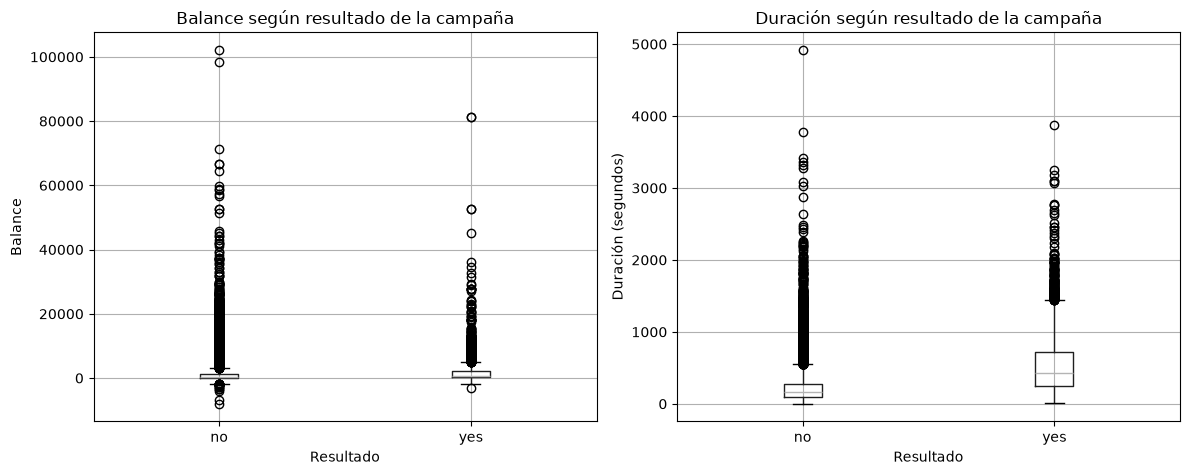

In [10]:
# Distribución de variables numéricas según el target

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column="balance", by="y", ax=axes[0])
axes[0].set_title("Balance según resultado de la campaña")
axes[0].set_xlabel("Resultado")
axes[0].set_ylabel("Balance")

df.boxplot(column="duration", by="y", ax=axes[1])
axes[1].set_title("Duración según resultado de la campaña")
axes[1].set_xlabel("Resultado")
axes[1].set_ylabel("Duración (segundos)")

plt.suptitle("")
plt.tight_layout()
plt.show()

**Interpretación**

El boxplot de `balance` muestra una distribución altamente dispersa y con numerosos valores extremos en ambas clases. La clase `yes` presenta una mediana superior a `no`, aunque existe un amplio solapamiento entre ambas distribuciones. Por lo tanto, aunque el balance presenta diferencias entre los grupos, los valores por sí solos no permiten una separación clara entre clientes que aceptan y no aceptan la oferta.

En `duration` se observa una diferencia más marcada entre las clases. Los clientes que aceptaron la oferta (`yes`) presentan una mediana y una distribución de duraciones claramente superiores a los clientes que no la aceptaron (`no`). También se observan numerosos valores extremos en ambas clases.

Sin embargo, esta relación debe interpretarse con precaución, ya que `duration` corresponde a la duración de la llamada y su valor solamente se conoce durante o después de la interacción con el cliente.

**Decisión**

Se conservará `balance` como variable predictora y no se eliminarán automáticamente sus valores extremos, ya que pueden representar situaciones reales de los clientes. Su comportamiento será considerado durante el preprocesamiento y modelado.

Aunque `duration` presenta una fuerte relación con el resultado de la campaña, se considera una variable con potencial de data leakage para un modelo que pretenda predecir la aceptación antes o al inicio de la llamada. Por esta razón, se evaluará su exclusión de las variables predictoras en la etapa de modelado.

---

### 4. Relación entre variables categóricas y la variable objetivo

Se analiza la relación entre las variables categóricas y la variable objetivo `y` mediante la tasa de aceptación de cada categoría. El objetivo es identificar si existen diferencias en la probabilidad de contratación entre los distintos grupos de clientes y determinar si estas variables aportan información relevante para el modelado.

In [11]:
# Variables categóricas

variables_categoricas = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

print("Variables categóricas:")
print(variables_categoricas)

Variables categóricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [12]:
# Tasa de aceptación por categoría

for col in variables_categoricas:
    
    tasa = pd.crosstab(
        df[col],
        df["y"],
        normalize="index"
    ) * 100
    
    print(f"\n--- {col} ---")
    print(tasa.round(2))


--- job ---
y                 no    yes
job                        
admin.         87.80  12.20
blue-collar    92.73   7.27
entrepreneur   91.73   8.27
housemaid      91.21   8.79
management     86.24  13.76
retired        77.21  22.79
self-employed  88.16  11.84
services       91.12   8.88
student        71.32  28.68
technician     88.94  11.06
unemployed     84.50  15.50
unknown        88.19  11.81

--- marital ---
y            no    yes
marital               
divorced  88.05  11.95
married   89.88  10.12
single    85.05  14.95

--- education ---
y             no    yes
education              
primary    91.37   8.63
secondary  89.44  10.56
tertiary   84.99  15.01
unknown    86.43  13.57

--- default ---
y           no    yes
default              
no       88.20  11.80
yes      93.62   6.38

--- housing ---
y          no   yes
housing            
no       83.3  16.7
yes      92.3   7.7

--- loan ---
y        no    yes
loan              
no    87.34  12.66
yes   93.32   6.68

--- con

**Interpretación**

Se observan diferencias en la tasa de aceptación entre las categorías de varias variables. Las diferencias más marcadas aparecen en `poutcome`, `month` y `job`, mientras que `marital` presenta diferencias más pequeñas entre sus categorías. También se observan diferencias en `housing`, `loan` y `contact`, aunque de menor magnitud.

**Decisión**

Se conservarán las variables categóricas para el modelado, ya que algunas muestran diferencias relevantes en la tasa de aceptación. Se profundizará principalmente en `poutcome`, `month` y `job`, mientras que las variables con diferencias menores se mantendrán sin realizar análisis adicionales por el momento.

**Análisis `poutcome`**

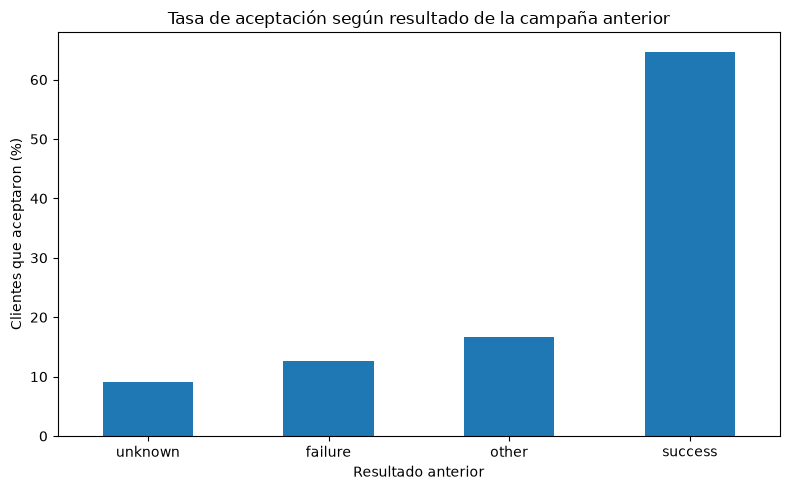

In [13]:
# Tasa de aceptación según el resultado de la campaña anterior

tasa_poutcome = pd.crosstab(
    df["poutcome"],
    df["y"],
    normalize="index"
) * 100

tasa_poutcome["yes"].sort_values().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Tasa de aceptación según resultado de la campaña anterior")
plt.xlabel("Resultado anterior")
plt.ylabel("Clientes que aceptaron (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [14]:
# Relación entre contactos previos y resultado de la campaña anterior

pd.crosstab(
    df["previous"] > 0,
    df["poutcome"],
    normalize="index"
).round(3)

poutcome,failure,other,success,unknown
previous,,,,
False,0.000,0.000,0.000,1.000
True,0.594,0.223,0.183,0.001


In [15]:
# Casos donde no hubo contactos previos pero aparece un resultado de campaña anterior

casos_inconsistentes = df[
    (df["previous"] == 0) &
    (df["poutcome"] != "unknown")
]

print("Casos:", len(casos_inconsistentes))

Casos: 0
